### Importing necessary modules

In [501]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
import tensorflow as tf                                                                 # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import dump, load                                                           # type: ignore
import random                                                                           # type: ignore
import cartopy.crs as ccrs                                                              # type: ignore
import cartopy.feature as cfeature                                                      # type: ignore
#np.random.seed(42)                                      
from netCDF4 import Dataset                                                             # type: ignore
import shap                                                                             # type: ignore
shap.initjs()

In [502]:
location = "Airmountain"

In [503]:
geodata = Dataset("/home/mendrika/mendrika-phd/codes/nflics/geoloc_grids/nxny1640_580_nxnyds164580_blobdx0.04491576_area4_n23_20_32.nc")
test_data = pd.read_csv(f"/home/mendrika/mendrika-phd/data/other-location/AirMountain/full-data-test-5nearest-AirMountain-different-lead-times.csv", index_col=False)

In [504]:
geodata

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    nx: 1640
    ny: 580
    nx_dakarstrip: 164
    ny_dakarstrip: 580
    blob_dx: 0.04491576
    dimensions(sizes): ys_edge(557), xs_edge(1804), ys_mid(556), xs_mid(1803), coord(4), xs(1225), ys(357)
    variables(dimensions): int64 ys_edge(ys_edge), int64 xs_edge(xs_edge), float64 lats_edge(ys_edge, xs_edge), float64 lons_edge(ys_edge, xs_edge), int64 ys_mid(ys_mid), int64 xs_mid(xs_mid), float64 lats_mid(ys_mid, xs_mid), float64 lons_mid(ys_mid, xs_mid), float64 area(ys_mid, xs_mid), float64 dfc_km(ys_edge, xs_edge), int64 dfc_pt(ys_edge, xs_edge), <class 'str'> coord(coord), int64 grid_lims_p(coord), int64 plot_area(coord), int64 xs(xs), float64 blobs_lons(xs), int64 ys(ys), float64 blobs_lats(ys)
    groups: 

### Importing dataset

### Exploratory data analysis

In [505]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [506]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [507]:
# Presence or absence of convection in Dakar at time t+1
target_index = "Cb_Dakar"

# Input at time t0
t0 = "year,month,day,hour,minute,"

# latitude and longitude, wavelet power, storm size and distance to Dakar
latlon = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    latlon += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"

# combining all fields to form the feature input
features = t0 + latlon + wavelet_power + storm_size + distance
field =  features #+ target_index
field = field.split(',')

In [508]:
to_scale = wavelet_power + storm_size + distance

In [509]:
lead_time = 6

In [510]:
model = tf.keras.models.load_model(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/{location}-t{lead_time}.keras")

In [511]:
scaler = load(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/scaler-AirMountain-t{lead_time}.bin')

In [513]:
raw_artificial_storm_data = pd.read_csv(f"test-data-from-latlon-map-AirMountain-{step}-corrected-1800.csv")

In [514]:
def prepare_for_test(df):
    df = log_transform(df, to_scale.split(',')[:-1])
    df = sqrt_transform(df, t0.split(',')[:-1])
    return df

In [515]:
artificial_storm_data = prepare_for_test(raw_artificial_storm_data)
x_new = artificial_storm_data[raw_artificial_storm_data.keys()]
x_new_std = scaler.transform(x_new)
y_new_pred = model.predict(x_new_std)

619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [516]:
y_new_pred[y_new_pred > 0.9].shape

(0,)

In [517]:
from scipy.ndimage import gaussian_filter  # type: ignore

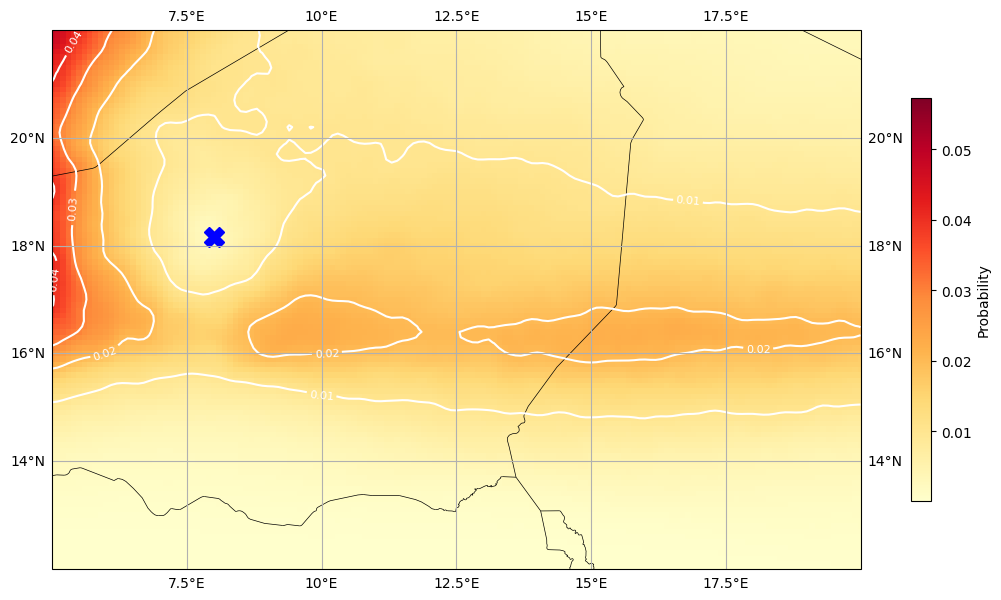

In [518]:
fig = plt.figure(figsize=(13, 7))


longitude = np.arange(5, 20+step, step)
latitude = np.arange(12, 25+step, step)

lons, lats = np.meshgrid(longitude, latitude)


ax = plt.axes(projection=ccrs.PlateCarree())

extent = (5, 20, 12, 22)

ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, edgecolor='gray')
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)
ax.gridlines(xlocs=np.array([5, 7.5, 10, 12.5, 15, 17.5]), ylocs=np.array([10, 14, 16, 18, 20]), draw_labels=True, crs=ccrs.PlateCarree())


prob = y_new_pred.flatten().reshape(lons.shape).round(4)

prob = gaussian_filter(prob, sigma=1.5)

plt.pcolormesh(lons, lats, prob, cmap="YlOrRd")
plt.colorbar(label='Probability', fraction=0.02)
contour = plt.contour(lons, lats, prob, colors='white', levels=5)
plt.clabel(contour, inline=True, fontsize=8)

location_lat = 18.166
location_lon = 8.0
plt.plot(location_lon, location_lat, "X", color="blue", markersize=15)

#fig.text(0.45, 0.1, "Longitude", ha='center')
#fig.text(0.07, 0.5, "Latitude", va='center', rotation='vertical')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()
plt.show()

#### SHAP

In [519]:
def f(x):
    return model.predict(x).flatten()

In [520]:
def select(df):
    selection_index_lat = df["lat5"] < 30
    selection_index_lon = df["lon5"] < 30
    selection_index = selection_index_lat * selection_index_lon
    return selection_index

In [521]:
index_test = select(test_data)
test_data = test_data[index_test]
test_data = test_data[field[:-1]]

In [522]:
variable = "ds"
for i in range(5):
    print(np.min(test_data[f"{variable}{i+1}"]), np.max(test_data[f"{variable}{i+1}"]))

1.0 379.08
9.0 395.81
18.6 500.0
18.68 500.0
0.0 500.0


In [523]:
#test_data = raw_artificial_storm_data
original_test_data = prepare_for_test(test_data)

In [524]:
original_test_data = original_test_data[field[:-1]]

In [525]:
X = scaler.transform(original_test_data)

In [526]:
index = f(X) > 0.1
X = X[index]
X_display = test_data[index]

  1/294 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step

294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [527]:
X.shape

(1008, 30)

In [528]:
explainer = shap.DeepExplainer(model, X)

/home/mendrika/anaconda3/lib/python3.10/site-packages/shap/explainers/_deep/deep_tf.py:99: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn("Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.")


In [529]:
n_shap = 1000

In [530]:
shap_values = explainer.shap_values(X[:n_shap])

In [531]:
if isinstance(shap_values, list):
    shap_values = shap_values[0]

In [532]:
for i in range(5):
    print(np.min(test_data[f"size{i+1}"]), np.max(test_data[f"size{i+1}"]))

100 72750
100 72750
0 61600
0.0 66900.0
0.0 54150.0


In [533]:
shap_values = shap_values[:, :, 0]

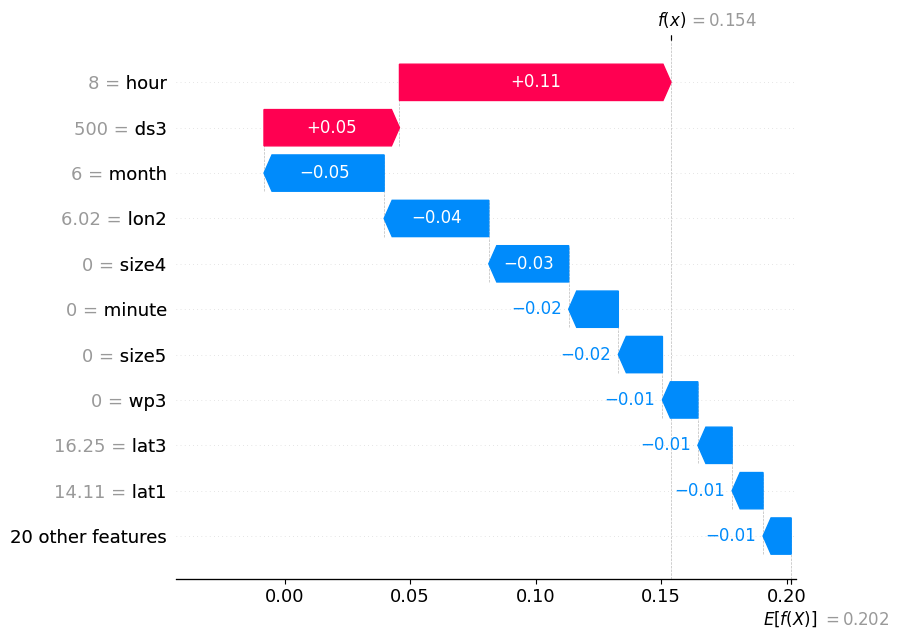

In [534]:
exp = shap.Explanation(shap_values[7], 
                       explainer.expected_value[0].numpy(),
                       feature_names=X_display.columns,
                       data=X_display.iloc[7,:]
                       )

shap.waterfall_plot(exp, 
                    max_display=11)

In [535]:
shap.plots.force(exp)

In [536]:
shap_values.shape

(1000, 30)

In [537]:
exp_many = shap.Explanation(shap_values, 
                                 explainer.expected_value[0].numpy(),
                                 data=X[:n_shap],
                                 feature_names=X_display.columns
                                 )

# shap.force_plot(exp_many, features=X_display.iloc[:n_shap],)

#### Absolute mean SHAP plot

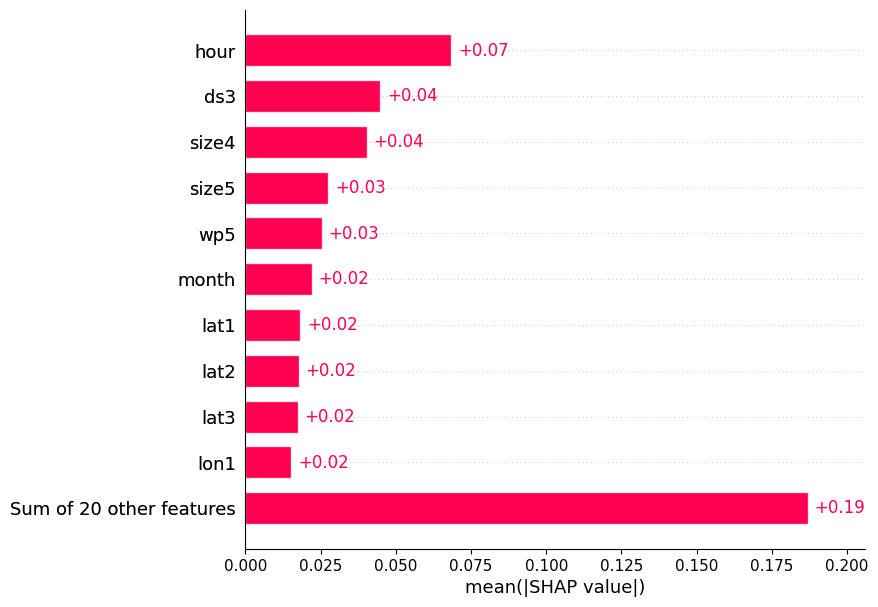

In [538]:
shap.plots.bar(exp_many, max_display=11)

#### Beeswarm plot

#### Violin plot

/home/mendrika/anaconda3/lib/python3.10/site-packages/shap/plots/_violin.py:271: UserWarning: not enough data in bin #12 for feature hour, so it'll be ignored. Try increasing the number of records to plot.
  warnings.warn(
/home/mendrika/anaconda3/lib/python3.10/site-packages/shap/plots/_violin.py:271: UserWarning: not enough data in bin #14 for feature hour, so it'll be ignored. Try increasing the number of records to plot.
  warnings.warn(
/home/mendrika/anaconda3/lib/python3.10/site-packages/shap/plots/_violin.py:271: UserWarning: not enough data in bin #16 for feature hour, so it'll be ignored. Try increasing the number of records to plot.
  warnings.warn(


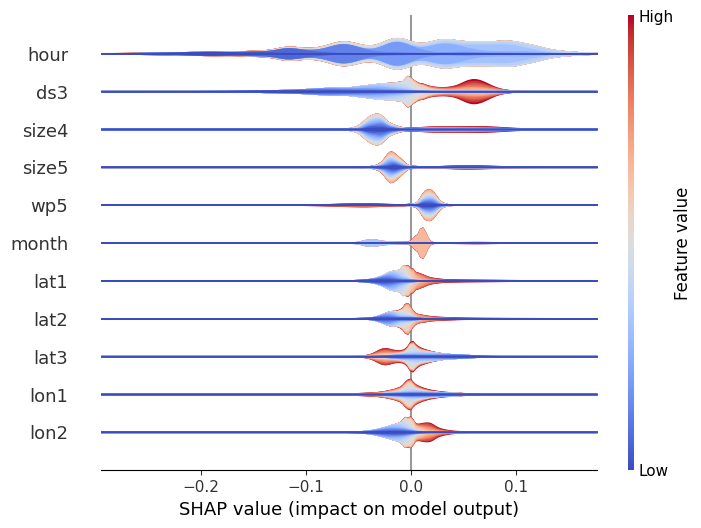

In [539]:
shap.plots.violin(exp_many, plot_type="layered_violin", max_display=11)

#### Dependence plots

In [540]:
exp_many.shape

(1000, 30)

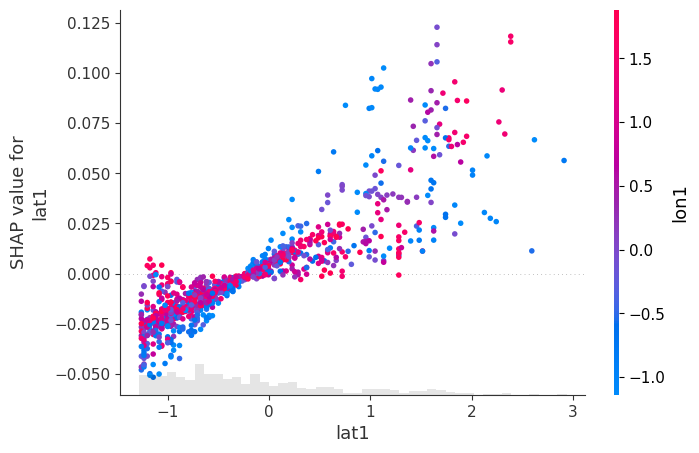

In [541]:
id = 1
shap.plots.scatter(exp_many[:, f"lat{id}"], 
                   color=exp_many[:, f"lon{id}"], 
                   )

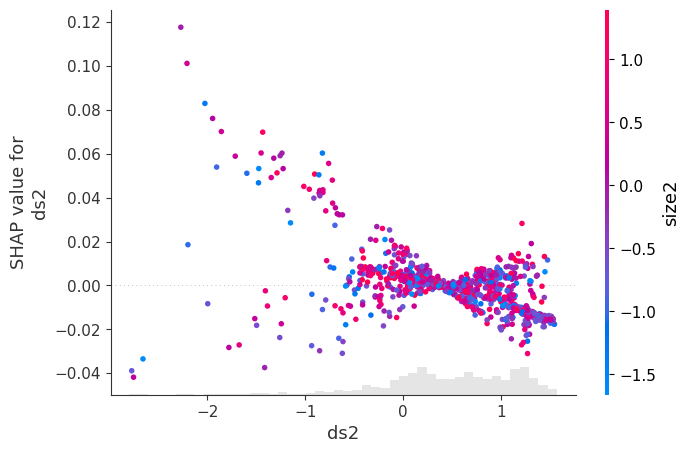

In [542]:
id = 2
shap.plots.scatter(exp_many[:, f"ds{id}"], color=exp_many[:, f"size{id}"])

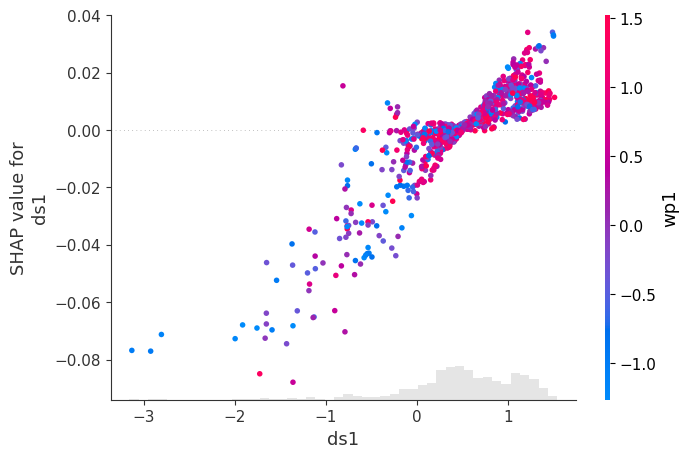

In [543]:
id = 1
shap.plots.scatter(exp_many[:, f"ds{id}"], color=exp_many[:, f"wp{id}"])

#### Heatmap

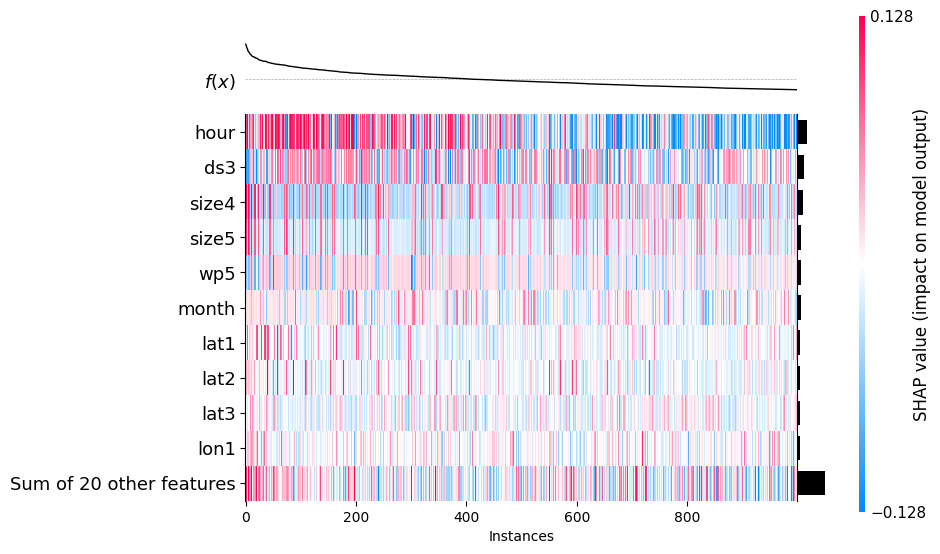

<AxesSubplot: xlabel='Instances'>

In [544]:
shap.plots.heatmap(exp_many, 
                   max_display=11,
                   instance_order=exp_many.sum(1))

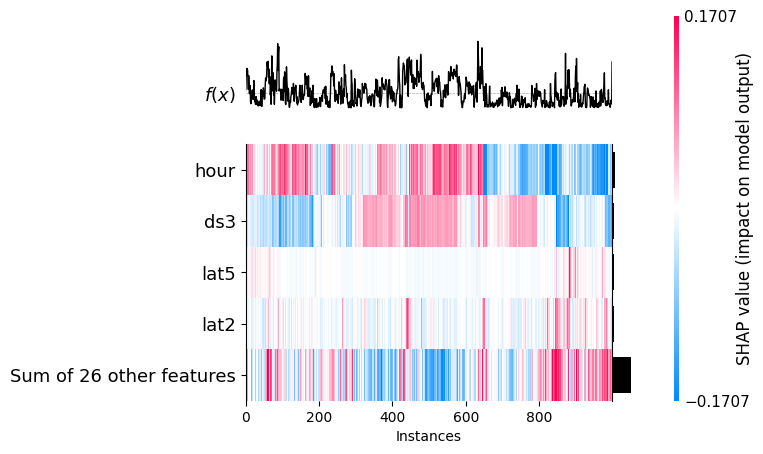

<AxesSubplot: xlabel='Instances'>

In [545]:
shap.plots.heatmap(exp_many, 
                   max_display=5,
                   feature_values=exp_many.abs.max(0))